<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v1.0</br>
📅 Last Updated: 2025-10-16</br>
</div>

</br>

<font color='#02e9fa'><b>**🚩 학습목표**</b></font></br>
이미지의 필터 적용 모습을 시각적으로 확인해봅시다.

</br>

In [3]:
# TODO 0: 데이터 준비를 위해 실행해주세요.
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('Cat03.jpg')
img = img.resize((64, 64))
img_array = np.array(img)
sample_image_rgb = torch.tensor(img_array, dtype=torch.float32).permute(0, 1, 2) / 255.0

print(f"이미지 크기: {sample_image_rgb.shape}")
print(f"픽셀 값 범위: [{sample_image_rgb.min():.3f}, {sample_image_rgb.max():.3f}]")

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/Day_05_CNN실습 (3-1)/Practice_분할버전/Cat03.jpg'

</br>

## 이미지 분석
> 이미지의 RGB 채널을 확인해봅시다.

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(sample_image_rgb)
plt.title(f'Original RGB Image\n{sample_image_rgb.shape}')
plt.axis('off')

colors = ['Reds', 'Greens', 'Blues']
channel_names = ['Red', 'Green', 'Blue']

for i in range(3):
    plt.subplot(1, 4, i+2)
    plt.imshow(sample_image_rgb[:, :, i], cmap=colors[i])
    plt.title(f'{channel_names[i]} Channel')
    plt.colorbar()
    plt.axis('off')

plt.tight_layout()
plt.show()

</br>

## Convolution Layer
> Convolution Layer는 이미지에서 지역적 특징을 추출을 담당합니다.

</br>

### 필터 정의
> 컨볼루션은 필터(커널)를 이미지 위에서 슬라이딩하여 특징을 추출하는 핵심 연산입니다.

In [29]:
# TODO 1: 다양한 필터를 정의해봅시다.

# 가장자리 검출 필터 (Edge Detection)
edge_filter = torch.tensor([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=torch.float32)

# 수직 가장자리 검출 (Vertical Edge)
vertical_filter = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=torch.float32)

# 수평 가장자리 검출 (Horizontal Edge)
horizontal_filter = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=torch.float32)

# 블러 필터 (Blur)
blur_filter = torch.tensor([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=torch.float32) / 9

filters = {
    'Edge Detection': edge_filter,
    'Vertical Edge': vertical_filter,
    'Horizontal Edge': horizontal_filter,
    'Blur': blur_filter
}

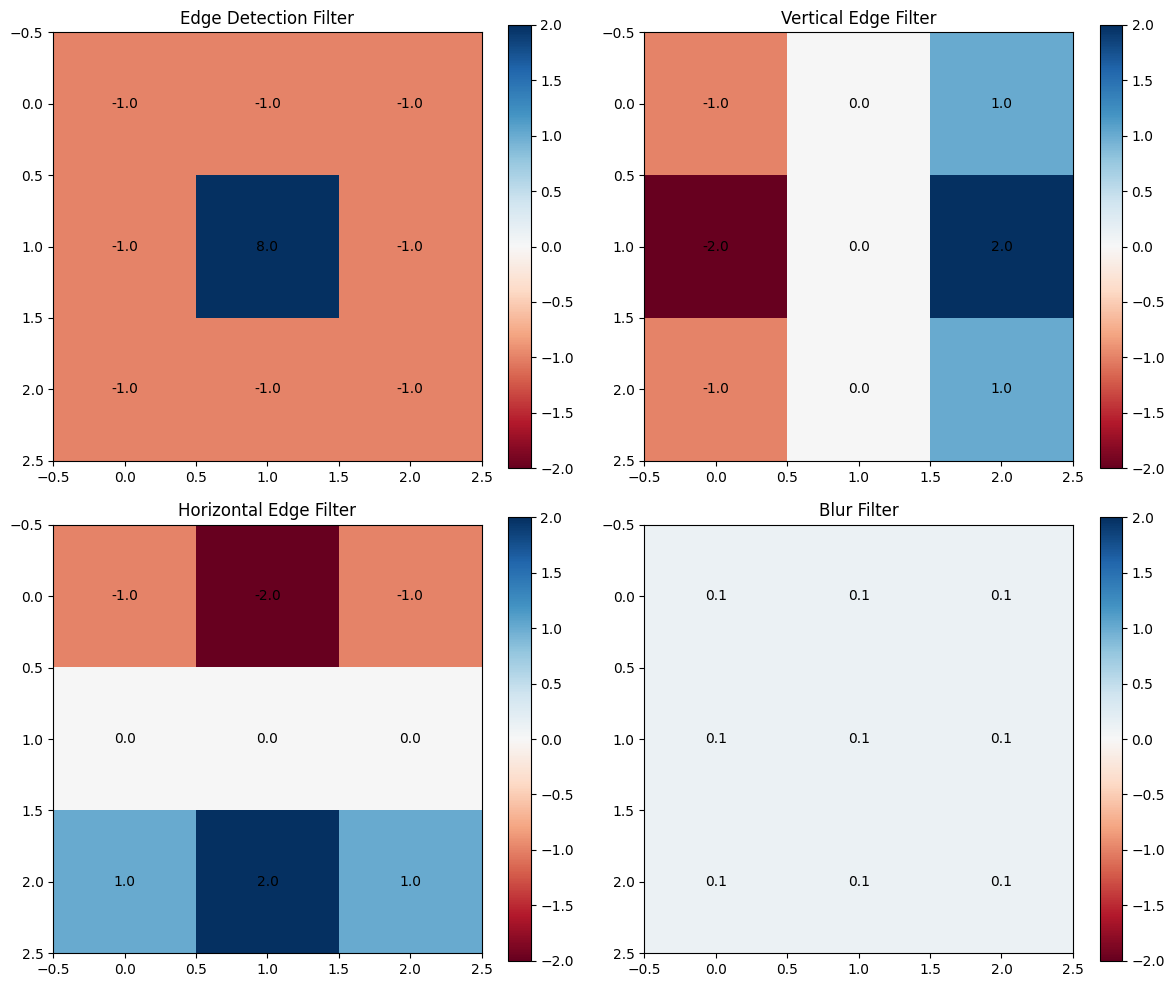

In [30]:
# TODO 2: 필터의 형태를 시각화해봅시다.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, filter_tensor) in enumerate(filters.items()):
    im = axes[idx].imshow(filter_tensor, cmap='RdBu', vmin=-2, vmax=2)
    axes[idx].set_title(f'{name} Filter', fontsize=12)

    # 각 셀에 값 표시
    for i in range(3):
        for j in range(3):
            axes[idx].text(j, i, f'{filter_tensor[i, j]:.1f}',
                          ha='center', va='center', fontsize=10)

    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

</br>

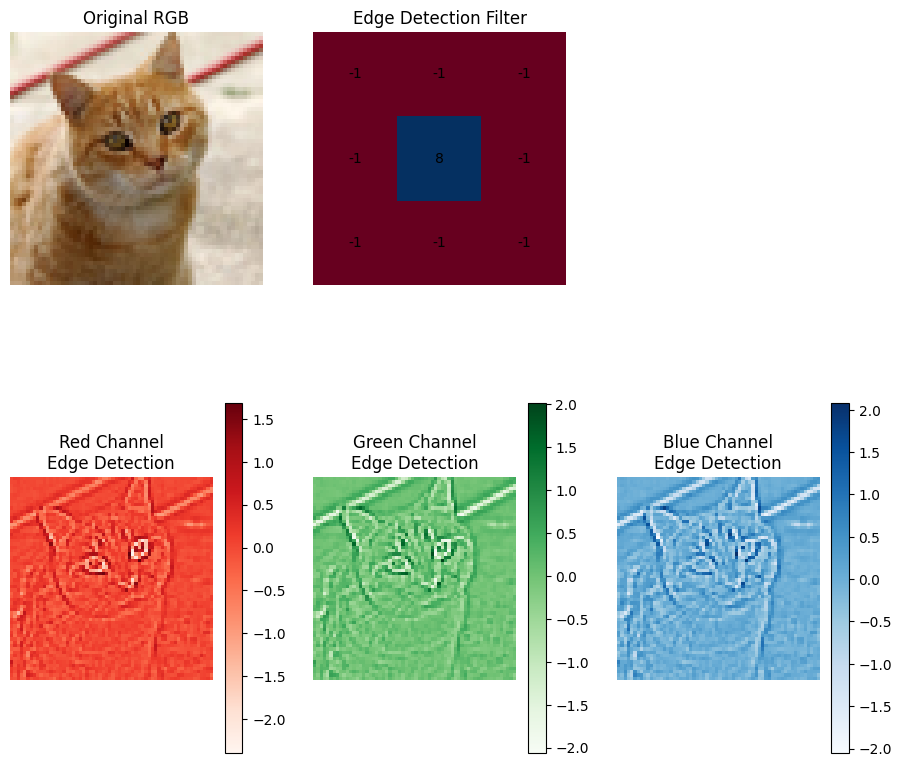

In [34]:
# TODO 3: Edge Filter를 적용한 시각화 결과를 확인해봅시다.
def manual_convolution_rgb(input_tensor, kernel, stride=1, padding=0):
    input_h, input_w, channels = input_tensor.shape
    kernel_h, kernel_w = kernel.shape

    # Apply padding if needed
    if padding > 0:
        # Pad height and width dimensions only, not channels
        input_tensor = F.pad(input_tensor.permute(2, 0, 1),
                           (padding, padding, padding, padding)).permute(1, 2, 0)
        input_h, input_w = input_tensor.shape[0], input_tensor.shape[1]

    # Calculate output size
    output_h = (input_h - kernel_h) // stride + 1
    output_w = (input_w - kernel_w) // stride + 1

    # Initialize output for each channel (H, W, C)
    output = torch.zeros(output_h, output_w, channels)

    # Apply convolution to each channel
    for c in range(channels):
        for i in range(output_h):
            for j in range(output_w):
                region = input_tensor[i*stride:i*stride+kernel_h,
                                    j*stride:j*stride+kernel_w, c]
                output[i, j, c] = torch.sum(region * kernel)

    return output

# Apply edge detection to RGB image
rgb_result = manual_convolution_rgb(sample_image_rgb, edge_filter)

# Visualize results
plt.figure(figsize=(15, 10))

# Original images
plt.subplot(2, 4, 1)
plt.imshow(sample_image_rgb)
plt.title('Original RGB')
plt.axis('off')

# Edge filter
plt.subplot(2, 4, 2)
plt.imshow(edge_filter, cmap='RdBu')
plt.title('Edge Detection Filter')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{edge_filter[i, j]:.0f}',
                ha='center', va='center', fontsize=10)
plt.axis('off')

# RGB channel results
colors = ['Reds', 'Greens', 'Blues']
channel_names = ['Red', 'Green', 'Blue']

for i in range(3):
    plt.subplot(2, 4, i+5)
    plt.imshow(rgb_result[:, :, i], cmap=colors[i])  # Extract each channel from (H,W,C)
    plt.title(f'{channel_names[i]} Channel\nEdge Detection')
    plt.colorbar()
    plt.axis('off')


=== Convolution Process Visualization ===
Let's see how convolution works on each RGB channel:

Red Channel Convolution:


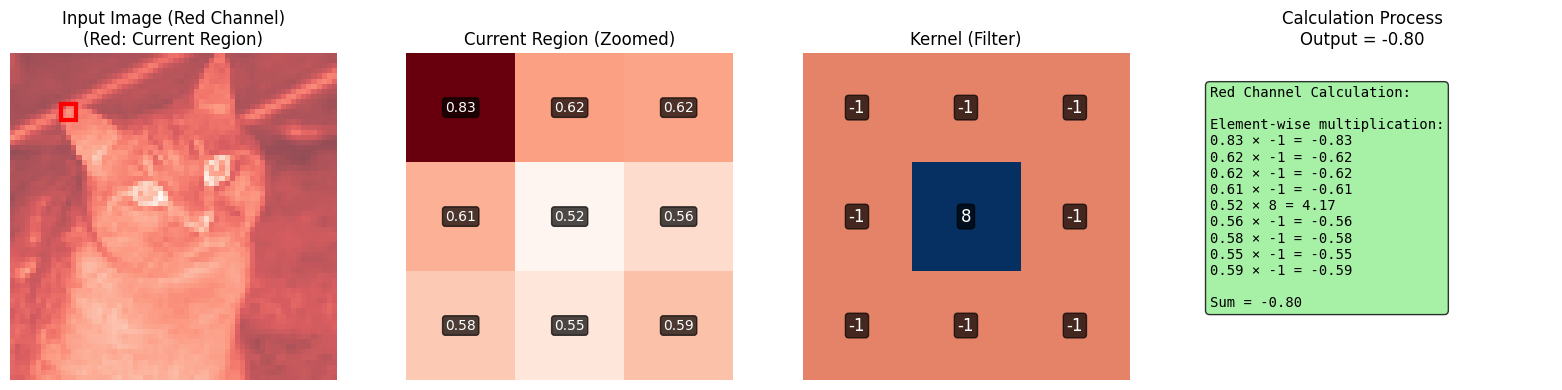

Output value: -0.80

Green Channel Convolution:


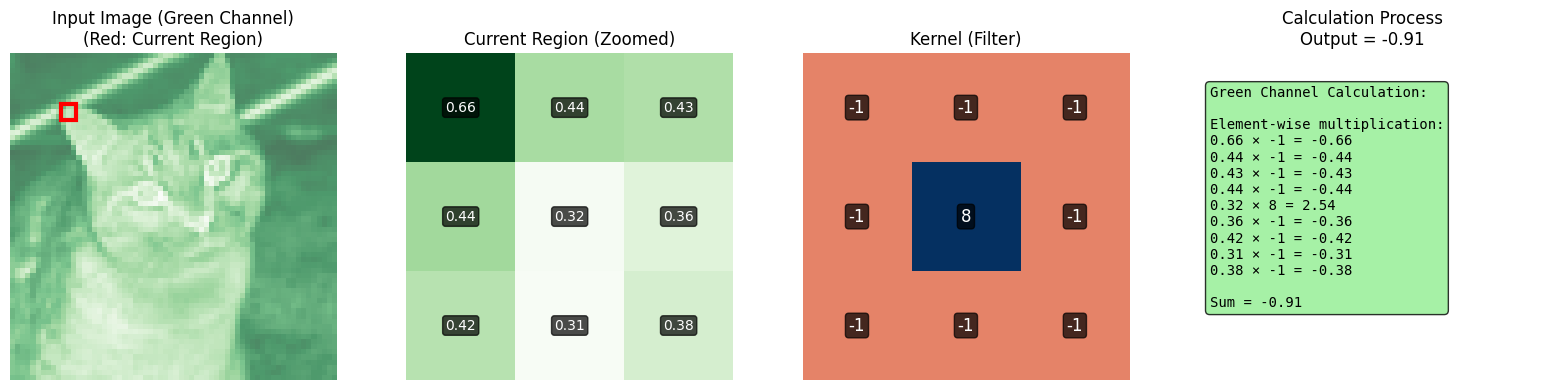

Output value: -0.91

Blue Channel Convolution:


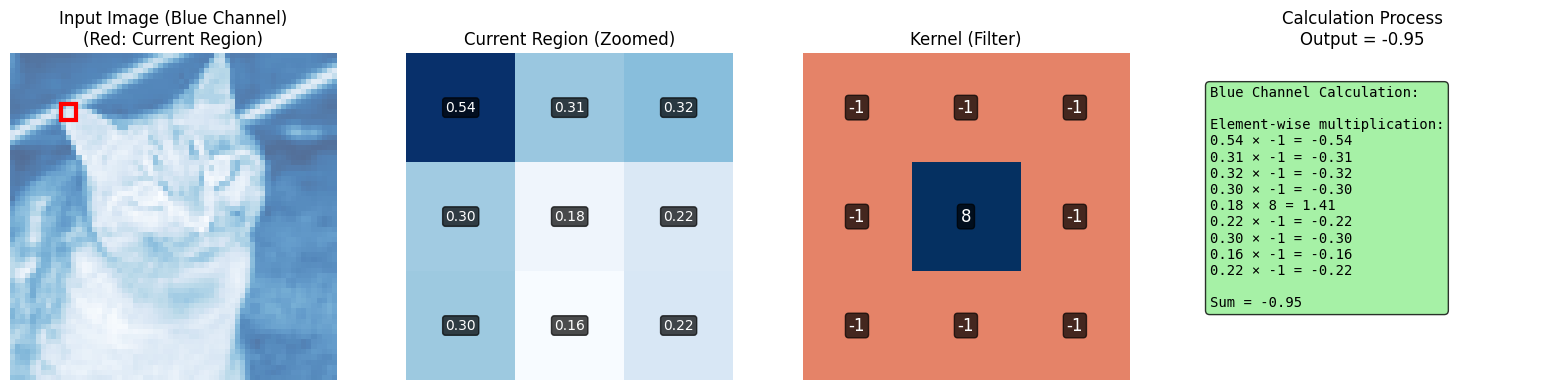

Output value: -0.95


In [39]:
def visualize_convolution_step_rgb(input_img, kernel, step_i, step_j, channel=0, stride=1):
    """
    Visualize a specific step of convolution for RGB images
    input_img: (H, W, C) format RGB image
    channel: which channel to visualize (0=Red, 1=Green, 2=Blue)
    """
    # Extract the specific channel for visualization
    if len(input_img.shape) == 3:  # RGB image
        channel_img = input_img[:, :, channel]
        channel_names = ['Red', 'Green', 'Blue']
        channel_name = channel_names[channel]
        colormap = ['Reds', 'Greens', 'Blues'][channel]
    else:  # Grayscale image
        channel_img = input_img
        channel_name = 'Grayscale'
        colormap = 'gray'

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # 1. Original image (current processing region highlighted)
    axes[0].imshow(channel_img, cmap=colormap, alpha=0.7)

    # Highlight current processing region
    kernel_h, kernel_w = kernel.shape
    rect = plt.Rectangle((step_j-0.5, step_i-0.5), kernel_w, kernel_h,
                        linewidth=3, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f'Input Image ({channel_name} Channel)\n(Red: Current Region)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('off')

    # 2. Current region zoomed in
    current_region = channel_img[step_i:step_i+kernel_h, step_j:step_j+kernel_w]
    im1 = axes[1].imshow(current_region, cmap=colormap)
    axes[1].set_title('Current Region (Zoomed)')
    for i in range(kernel_h):
        for j in range(kernel_w):
            axes[1].text(j, i, f'{current_region[i, j]:.2f}',
                        ha='center', va='center', fontsize=10, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    axes[1].axis('off')

    # 3. Kernel
    im2 = axes[2].imshow(kernel, cmap='RdBu', vmin=-2, vmax=2)
    axes[2].set_title('Kernel (Filter)')
    for i in range(kernel_h):
        for j in range(kernel_w):
            axes[2].text(j, i, f'{kernel[i, j]:.0f}',
                        ha='center', va='center', fontsize=12, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    axes[2].axis('off')

    # 4. Calculation process
    result = torch.sum(current_region * kernel).item()
    calculation_text = f"{channel_name} Channel Calculation:\n\n"
    calculation_text += "Element-wise multiplication:\n"
    total = 0
    for i in range(kernel_h):
        for j in range(kernel_w):
            product = (current_region[i,j] * kernel[i,j]).item()
            calculation_text += f"{current_region[i,j]:.2f} × {kernel[i,j]:.0f} = {product:.2f}\n"
            total += product
    calculation_text += f"\nSum = {total:.2f}"

    axes[3].text(0.1, 0.9, calculation_text, transform=axes[3].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    axes[3].set_title(f'Calculation Process\nOutput = {result:.2f}')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return result

# Demonstrate convolution step for each RGB channel
print("=== Convolution Process Visualization ===")
print("Let's see how convolution works on each RGB channel:")

step_i, step_j = 10, 10  # Choose a position with interesting features

for channel in range(3):
    channel_names = ['Red', 'Green', 'Blue']
    print(f"\n{channel_names[channel]} Channel Convolution:")
    result = visualize_convolution_step_rgb(sample_image_rgb, edge_filter,
                                          step_i, step_j, channel=channel)
    print(f"Output value: {result:.2f}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4039216..2.0745099].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8862746..2.1843138].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2745097..2.1764708].


Edge Detection filter result:
  - Output size: torch.Size([62, 62, 3])
  - Value range: [-2.40, 2.07]
  - Mean: -0.00

Vertical Edge filter result:
  - Output size: torch.Size([62, 62, 3])
  - Value range: [-2.89, 2.18]
  - Mean: 0.01

Horizontal Edge filter result:
  - Output size: torch.Size([62, 62, 3])
  - Value range: [-2.27, 2.18]
  - Mean: -0.05



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8862746..2.1843138].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2745097..2.1764708].


Blur filter result:
  - Output size: torch.Size([62, 62, 3])
  - Value range: [0.03, 0.99]
  - Mean: 0.57



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.86274517..1.5764706].


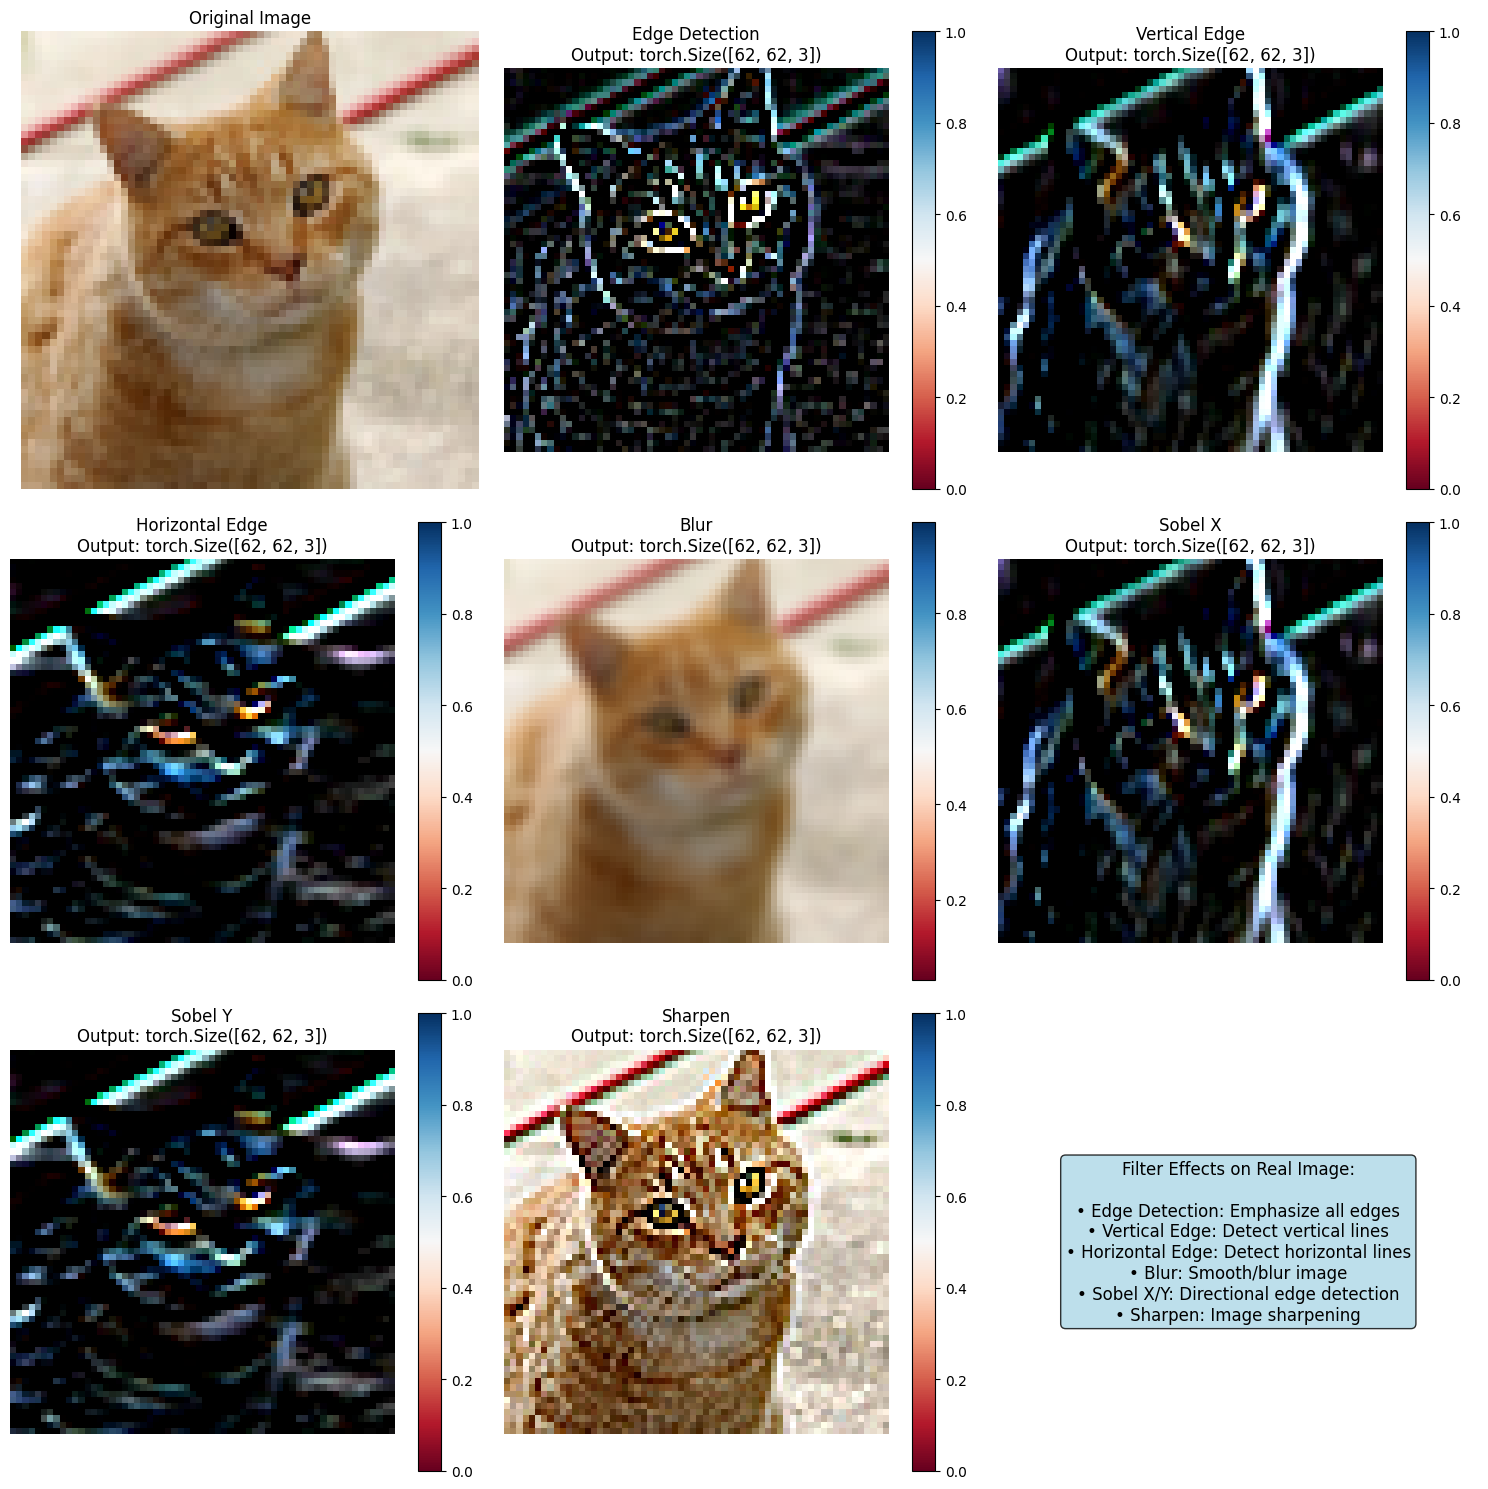

In [40]:
# TODO 5: Apply all filters to real image and compare results
def manual_convolution_rgb(input_tensor, kernel, stride=1, padding=0):
    input_h, input_w, channels = input_tensor.shape
    kernel_h, kernel_w = kernel.shape

    # Apply padding if needed
    if padding > 0:
        # Pad height and width dimensions only, not channels
        input_tensor = F.pad(input_tensor.permute(2, 0, 1),
                           (padding, padding, padding, padding)).permute(1, 2, 0)
        input_h, input_w = input_tensor.shape[0], input_tensor.shape[1]

    # Calculate output size
    output_h = (input_h - kernel_h) // stride + 1
    output_w = (input_w - kernel_w) // stride + 1

    # Initialize output for each channel (H, W, C)
    output = torch.zeros(output_h, output_w, channels)

    # Apply convolution to each channel
    for c in range(channels):
        for i in range(output_h):
            for j in range(output_w):
                region = input_tensor[i*stride:i*stride+kernel_h,
                                    j*stride:j*stride+kernel_w, c]
                output[i, j, c] = torch.sum(region * kernel)

    return output

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Original image
axes[0, 0].imshow(sample_image_rgb, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Apply each filter
filter_names = ['Edge Detection', 'Vertical Edge', 'Horizontal Edge', 'Blur']
filter_list = [edge_filter, vertical_filter, horizontal_filter, blur_filter]

positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

for idx, (name, filt) in enumerate(zip(filter_names, filter_list)):
    result = manual_convolution_rgb(sample_image_rgb, filt)
    row, col = positions[idx]

    im = axes[row, col].imshow(result, cmap='RdBu')
    axes[row, col].set_title(f'{name}\nOutput: {result.shape}')
    axes[row, col].axis('off')
    plt.colorbar(im, ax=axes[row, col])

    print(f"{name} filter result:")
    print(f"  - Output size: {result.shape}")
    print(f"  - Value range: [{result.min():.2f}, {result.max():.2f}]")
    print(f"  - Mean: {result.mean():.2f}")
    print()

# Additional filters (more effective on real images)
# Sobel X (enhanced vertical edge)
sobel_x = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=torch.float32)

# Sobel Y (enhanced horizontal edge)
sobel_y = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=torch.float32)

# Sharpening filter
sharpen_filter = torch.tensor([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=torch.float32)

# Apply additional filters
additional_filters = [
    ('Sobel X', sobel_x),
    ('Sobel Y', sobel_y),
    ('Sharpen', sharpen_filter)
]

additional_positions = [(1, 2), (2, 0), (2, 1)]

for idx, (name, filt) in enumerate(additional_filters):
    result = manual_convolution_rgb(sample_image_rgb, filt)
    row, col = additional_positions[idx]

    im = axes[row, col].imshow(result, cmap='RdBu')
    axes[row, col].set_title(f'{name}\nOutput: {result.shape}')
    axes[row, col].axis('off')
    plt.colorbar(im, ax=axes[row, col])

# Filter effects explanation
axes[2, 2].text(0.5, 0.5,
                "Filter Effects on Real Image:\n\n" +
                "• Edge Detection: Emphasize all edges\n" +
                "• Vertical Edge: Detect vertical lines\n" +
                "• Horizontal Edge: Detect horizontal lines\n" +
                "• Blur: Smooth/blur image\n" +
                "• Sobel X/Y: Directional edge detection\n" +
                "• Sharpen: Image sharpening",
                transform=axes[2, 2].transAxes, fontsize=12,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

Stride=1, Padding=0:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([62, 62, 3])
  Value range: [-2.40, 2.07]
  Size reduction: 6.2%

Stride=2, Padding=0:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([31, 31, 3])
  Value range: [-2.06, 1.69]
  Size reduction: 76.5%

Stride=1, Padding=1:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([64, 64, 3])
  Value range: [-2.40, 4.56]
  Size reduction: 0.0%

Stride=2, Padding=1:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([32, 32, 3])
  Value range: [-2.40, 4.18]
  Size reduction: 75.0%

Stride=1, Padding=2:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([66, 66, 3])
  Value range: [-2.93, 4.56]
  Size reduction: -6.3%

Stride=3, Padding=0:
  Input: torch.Size([64, 64, 3]) → Output: torch.Size([21, 21, 3])
  Value range: [-2.06, 1.44]
  Size reduction: 89.2%



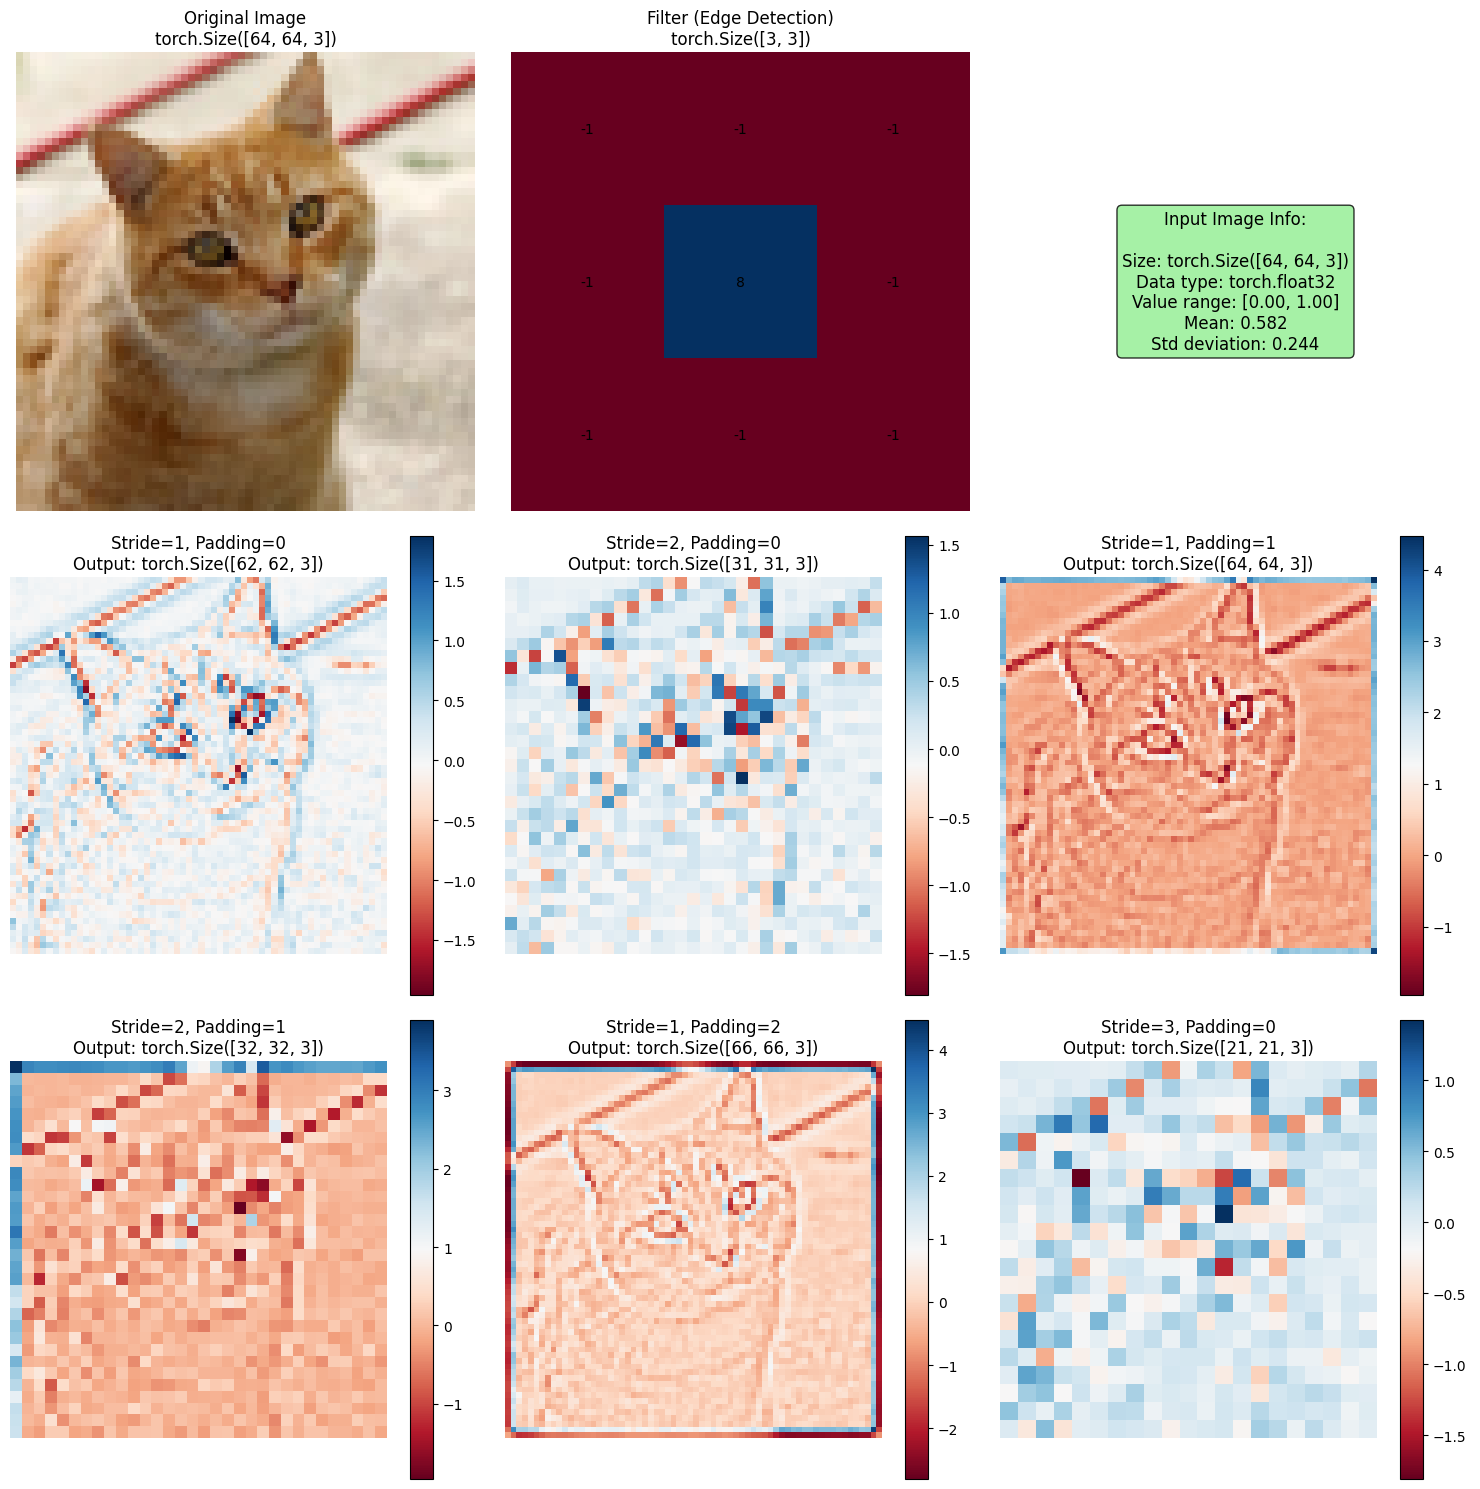


=== Detailed Stride Effect Analysis ===


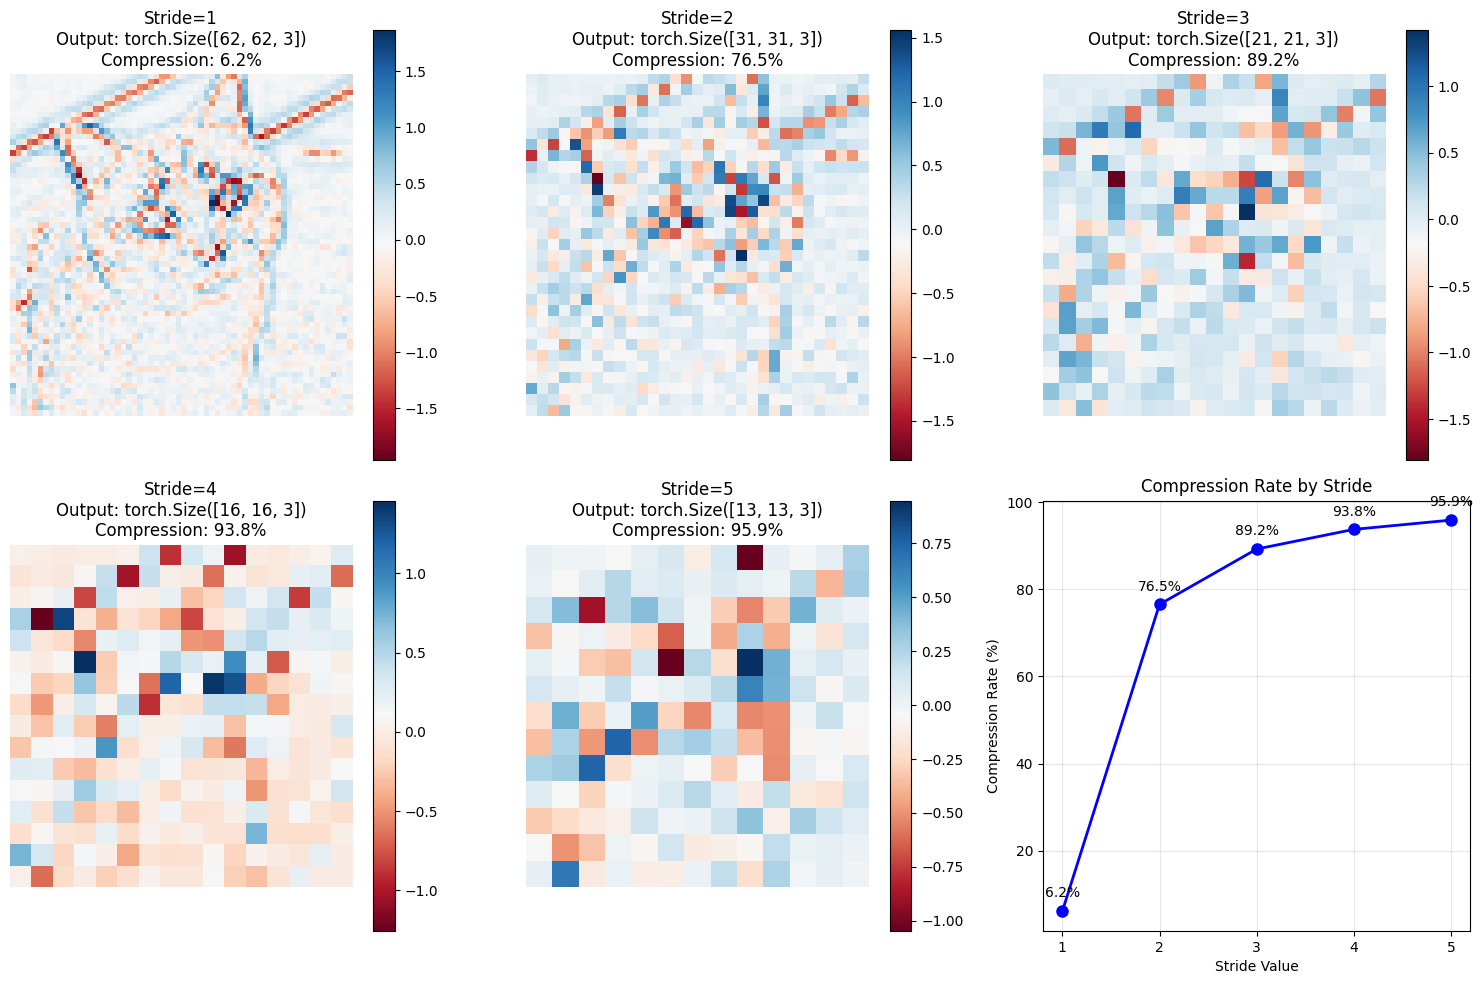

In [43]:
def demonstrate_stride_padding_real_image():
    # Use real RGB image
    real_image = sample_image_rgb

    # Use edge detection filter (clearer effect)
    kernel = edge_filter

    # Various configuration experiments
    configs = [
        {'stride': 1, 'padding': 0, 'title': 'Stride=1, Padding=0'},
        {'stride': 2, 'padding': 0, 'title': 'Stride=2, Padding=0'},
        {'stride': 1, 'padding': 1, 'title': 'Stride=1, Padding=1'},
        {'stride': 2, 'padding': 1, 'title': 'Stride=2, Padding=1'},
        {'stride': 1, 'padding': 2, 'title': 'Stride=1, Padding=2'},
        {'stride': 3, 'padding': 0, 'title': 'Stride=3, Padding=0'}
    ]

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    # Original image
    axes[0, 0].imshow(real_image)
    axes[0, 0].set_title(f'Original Image\n{real_image.shape}')
    axes[0, 0].axis('off')

    # Display kernel being used
    axes[0, 1].imshow(kernel, cmap='RdBu')
    axes[0, 1].set_title(f'Filter (Edge Detection)\n{kernel.shape}')
    axes[0, 1].axis('off')
    for i in range(3):
        for j in range(3):
            axes[0, 1].text(j, i, f'{kernel[i, j]:.0f}',
                           ha='center', va='center', fontsize=10)

    # Input image information
    axes[0, 2].text(0.5, 0.5,
                    f"Input Image Info:\n\n" +
                    f"Size: {real_image.shape}\n" +
                    f"Data type: {real_image.dtype}\n" +
                    f"Value range: [{real_image.min():.2f}, {real_image.max():.2f}]\n" +
                    f"Mean: {real_image.mean():.3f}\n" +
                    f"Std deviation: {real_image.std():.3f}",
                    transform=axes[0, 2].transAxes, fontsize=12,
                    ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    axes[0, 2].axis('off')

    # Results for each configuration
    positions = [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

    for idx, config in enumerate(configs):
        if idx >= len(positions):
            break

        result = manual_convolution_rgb(real_image, kernel,
                                  config['stride'], config['padding'])
        row, col = positions[idx]

        # Display combined RGB result (average across channels for visualization)
        result_display = result.mean(dim=2) if len(result.shape) == 3 else result
        im = axes[row, col].imshow(result_display, cmap='RdBu')
        axes[row, col].set_title(f"{config['title']}\nOutput: {result.shape}")
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col])

        # Print result statistics
        print(f"{config['title']}:")
        print(f"  Input: {real_image.shape} → Output: {result.shape}")
        print(f"  Value range: [{result.min():.2f}, {result.max():.2f}]")
        print(f"  Size reduction: {(1 - result.numel()/real_image.numel())*100:.1f}%")
        print()

    plt.tight_layout()
    plt.show()

    return real_image

# Run experiment with real image
real_img = demonstrate_stride_padding_real_image()

# Detailed analysis of stride effects
print("\n=== Detailed Stride Effect Analysis ===")
stride_values = [1, 2, 3, 4, 5]
original_size = real_img.numel()

plt.figure(figsize=(15, 10))

for i, stride in enumerate(stride_values):
    result = manual_convolution_rgb(real_img, edge_filter, stride=stride, padding=0)

    plt.subplot(2, 3, i+1)
    # Display combined result for visualization
    result_display = result.mean(dim=2) if len(result.shape) == 3 else result
    plt.imshow(result_display, cmap='RdBu')
    plt.title(f'Stride={stride}\nOutput: {result.shape}\nCompression: {(1-result.numel()/original_size)*100:.1f}%')
    plt.axis('off')
    plt.colorbar()

# Analysis graph in last subplot
plt.subplot(2, 3, 6)
output_sizes = []
compression_rates = []

for stride in stride_values:
    result = manual_convolution_rgb(real_img, edge_filter, stride=stride, padding=0)
    output_sizes.append(result.numel())
    compression_rates.append((1 - result.numel()/original_size) * 100)

plt.plot(stride_values, compression_rates, 'bo-', linewidth=2, markersize=8)
plt.title('Compression Rate by Stride')
plt.xlabel('Stride Value')
plt.ylabel('Compression Rate (%)')
plt.grid(True, alpha=0.3)
plt.xticks(stride_values)

for i, (stride, rate) in enumerate(zip(stride_values, compression_rates)):
    plt.annotate(f'{rate:.1f}%', (stride, rate),
                textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()